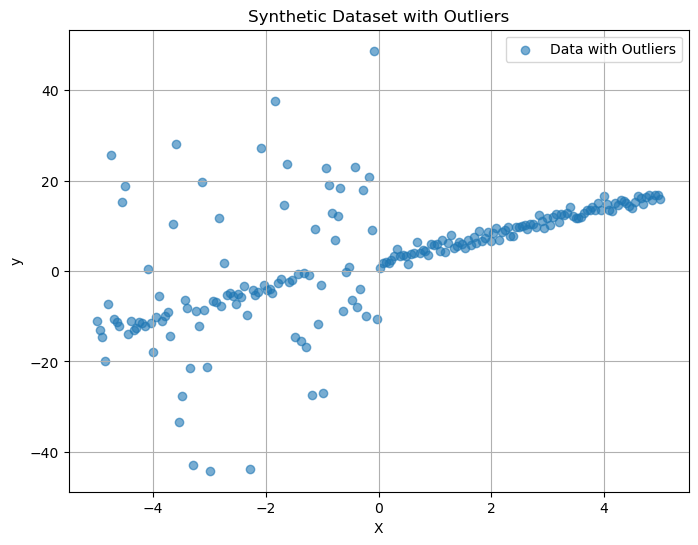

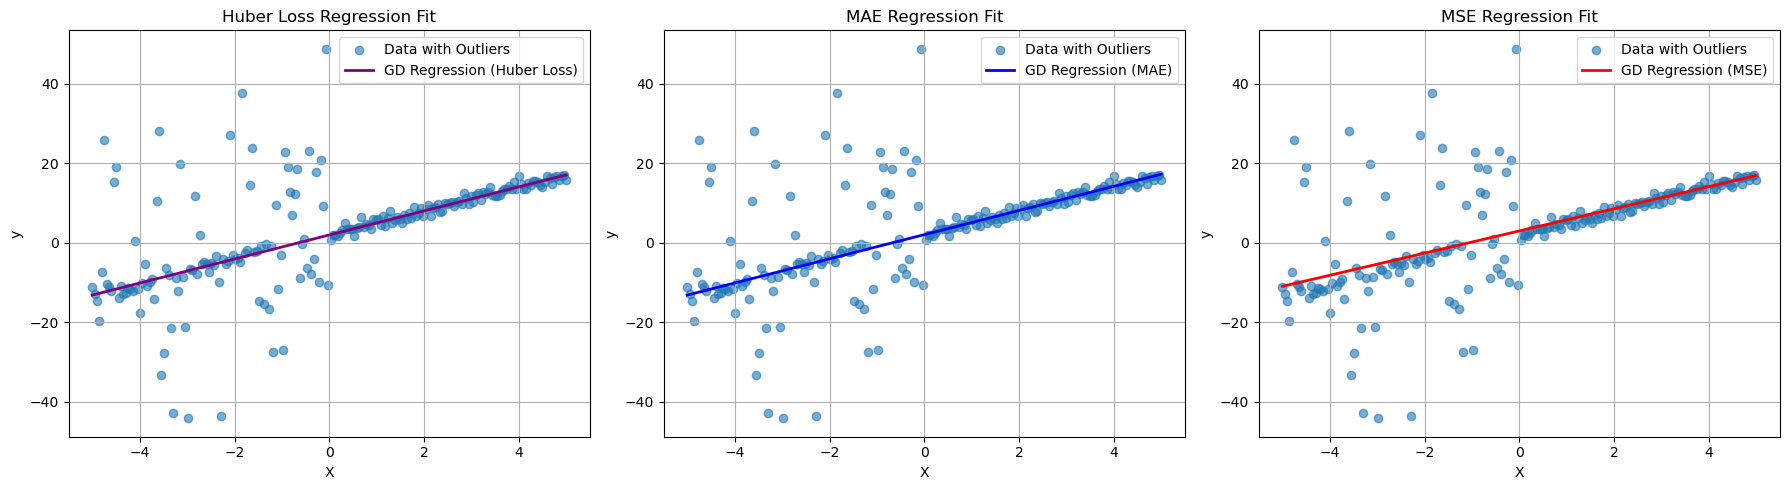

Huber Loss: 5.256235609017709
MAE Loss: 5.256235609017709
MSE Loss: 116.99466689842637


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generate synthetic dataset with clearer MSE differences
np.random.seed(42)
X = np.linspace(-5, 5, 200).reshape(-1, 1)
y_true = 3 * X.ravel() + 2

# Introduce more severe outliers, grouped on one side
y = y_true + np.random.normal(0, 1, size=X.shape[0])
outlier_indices = np.random.choice(len(y) // 2, size=60, replace=False)  # Grouped on one side
y[outlier_indices] += np.random.normal(0, 20, size=60)  # Change size to 60

# Plot the dataset before training
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label="Data with Outliers", alpha=0.6)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Dataset with Outliers")
plt.legend()
plt.grid()
plt.show()

# Gradient Descent Linear Regression with Huber Loss
class GradientDescentLinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, delta=1.0):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.delta = delta
        self.weights = None
        self.bias = None

    def huber_loss(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = np.abs(error) <= self.delta
        squared_loss = 0.5 * error ** 2
        linear_loss = self.delta * (np.abs(error) - 0.5 * self.delta)
        return np.where(is_small_error, squared_loss, linear_loss)

    def fit(self, X, y):
        # Initialize weights and bias
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent loop
        for _ in range(self.n_iterations):
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate gradients for Huber loss
            error = y_predicted - y
            is_small_error = np.abs(error) <= self.delta
            dw = (1 / n_samples) * np.dot(X.T, np.where(is_small_error, error, self.delta * np.sign(error)))
            db = (1 / n_samples) * np.sum(np.where(is_small_error, error, self.delta * np.sign(error)))

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train the custom gradient descent model with Huber loss
gd_model = GradientDescentLinearRegression(learning_rate=0.01, n_iterations=1000, delta=1.0)
gd_model.fit(X, y)

# Predictions
y_pred_gd_huber = gd_model.predict(X)

# Compute losses
mse_loss = mean_squared_error(y, y_pred_gd_huber)
mae_loss = mean_absolute_error(y, y_pred_gd_huber)

# Create a new model for MAE and MSE separately
class GradientDescentMAE:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate gradients for MAE
            error = y_predicted - y
            dw = (1 / n_samples) * np.dot(X.T, np.sign(error))
            db = (1 / n_samples) * np.sum(np.sign(error))

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train the custom gradient descent model with MAE
gd_model_mae = GradientDescentMAE(learning_rate=0.01, n_iterations=1000)
gd_model_mae.fit(X, y)
y_pred_gd_mae = gd_model_mae.predict(X)

# Train the custom gradient descent model with MSE
class GradientDescentMSE:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Calculate gradients for MSE
            error = y_predicted - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train the custom gradient descent model with MSE
gd_model_mse = GradientDescentMSE(learning_rate=0.01, n_iterations=1000)
gd_model_mse.fit(X, y)
y_pred_gd_mse = gd_model_mse.predict(X)

# Plot Regression Fit for Huber Loss
plt.figure(figsize=(18, 5))

# Huber Loss Regression Fit
plt.subplot(1, 3, 1)
plt.scatter(X, y, label="Data with Outliers", alpha=0.6)
plt.plot(X, y_pred_gd_huber, label="GD Regression (Huber Loss)", color='purple', linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Huber Loss Regression Fit")
plt.legend()
plt.grid()

# MAE Regression Fit
plt.subplot(1, 3, 2)
plt.scatter(X, y, label="Data with Outliers", alpha=0.6)
plt.plot(X, y_pred_gd_mae, label="GD Regression (MAE)", color='blue', linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("MAE Regression Fit")
plt.legend()
plt.grid()

# MSE Regression Fit
plt.subplot(1, 3, 3)
plt.scatter(X, y, label="Data with Outliers", alpha=0.6)
plt.plot(X, y_pred_gd_mse, label="GD Regression (MSE)", color='red', linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("MSE Regression Fit")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# Print losses
print(f"Huber Loss: {mean_absolute_error(y, y_pred_gd_huber)}")
print(f"MAE Loss: {mae_loss}")
print(f"MSE Loss: {mse_loss}")
